 # Project 7: Explanatory Data Analysis & Advanced Visualization (Baby Names Dataset)

## First Inspection: The most popular Names in 2018

1. __Load__ and __inspect__ the dataset "us_baby_names.csv". __Save__ the DataFrame in __df__.

2. Find the most popular __Baby Girl Names__ in __2018__. 

3. Find the most popular __Baby Boy Names__ in __2018__.

4. __Create__ the function __most_pop(year, gender, n)__ that returns the __n__ most popular __M/F__ Names in the __year XYZ__.

In [36]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("us_baby_names.csv")
df

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
...,...,...,...,...
1957041,2018,Zylas,M,5
1957042,2018,Zyran,M,5
1957043,2018,Zyrie,M,5
1957044,2018,Zyron,M,5


In [3]:
df.nunique()

Year        139
Name      98400
Gender        2
Count     13720
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957046 entries, 0 to 1957045
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Year    int64 
 1   Name    object
 2   Gender  object
 3   Count   int64 
dtypes: int64(2), object(2)
memory usage: 59.7+ MB


In [5]:
df.Gender = df.Gender.astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957046 entries, 0 to 1957045
Data columns (total 4 columns):
 #   Column  Dtype   
---  ------  -----   
 0   Year    int64   
 1   Name    object  
 2   Gender  category
 3   Count   int64   
dtypes: category(1), int64(2), object(1)
memory usage: 46.7+ MB


In [6]:
names_2018 = df[df.Year == 2018].copy()
names_2018

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
...,...,...,...,...
1957041,2018,Zylas,M,5
1957042,2018,Zyran,M,5
1957043,2018,Zyrie,M,5
1957044,2018,Zyron,M,5


In [7]:
names_2018[names_2018.Gender == "F"].nlargest(10, "Count")

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
1925018,2018,Charlotte,F,12940
1925019,2018,Mia,F,12642
1925020,2018,Amelia,F,12301
1925021,2018,Harper,F,10582
1925022,2018,Evelyn,F,10376


In [8]:
def pop_name(year, gender, n):
    return df[(df.Year == year) & (df.Gender == gender)].nlargest(n, "Count") 

In [9]:
pop_name(2018, "M", 5)

,Year,Name,Gender,Count
1943042,2018,Liam,M,19837
1943043,2018,Noah,M,18267
1943044,2018,William,M,14516
1943045,2018,James,M,13525
1943046,2018,Oliver,M,13389


In [10]:
pop_name(2018, "F", 5)

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928


## Evergreen Names (1880 - 2018)

5. Find those __Evergreen Boy Names__ that are in __1880 and 2018__ among the most popular Boy Names (__Top 20__).

6. Find those __Evergreen Girl Names__ that are in __1880 and 2018__ among the most popular Girl Names (__Top 20__).

In [11]:
f_2018 = pop_name(2018, "F", 20)
f_2018

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
1925018,2018,Charlotte,F,12940
1925019,2018,Mia,F,12642
1925020,2018,Amelia,F,12301
1925021,2018,Harper,F,10582
1925022,2018,Evelyn,F,10376


In [12]:
f_1880 = pop_name(1880, "F", 20)
f_1880

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
5,1880,Margaret,F,1578
6,1880,Ida,F,1472
7,1880,Alice,F,1414
8,1880,Bertha,F,1320
9,1880,Sarah,F,1288


In [13]:
f_2018[["Name", "Count"]].merge(f_1880[["Name", "Count"]], how="inner", on="Name")

,Name,Count_x,Count_y
0,Emma,18688,2003
1,Elizabeth,8513,1939
2,Ella,8055,1156


In [14]:
f_evergiven = f_2018[["Name", "Count"]].merge(f_1880[["Name", "Count"]], how="inner", on="Name", suffixes=("_2018", "_1880"))
f_evergiven

,Name,Count_2018,Count_1880
0,Emma,18688,2003
1,Elizabeth,8513,1939
2,Ella,8055,1156


In [15]:
m_2018 = pop_name(2018, "M", 20)
m_2018

,Year,Name,Gender,Count
1943042,2018,Liam,M,19837
1943043,2018,Noah,M,18267
1943044,2018,William,M,14516
1943045,2018,James,M,13525
1943046,2018,Oliver,M,13389
1943047,2018,Benjamin,M,13381
1943048,2018,Elijah,M,12886
1943049,2018,Lucas,M,12585
1943050,2018,Mason,M,12435
1943051,2018,Logan,M,12352


In [16]:
m_1880 = pop_name(1880, "M", 20)

In [17]:
m_evergiven = m_2018[["Name", "Count"]].merge(m_1880[["Name", "Count"]], how="inner", on="Name", suffixes=("_2018", "_1880"))
m_evergiven

,Name,Count_2018,Count_1880
0,William,14516,9532
1,James,13525,5927
2,Henry,10649,2444


## Advanced Data Aggregation

7. Create the following __aggregated DataFrame agg__ (you can see the first and last 5 rows):

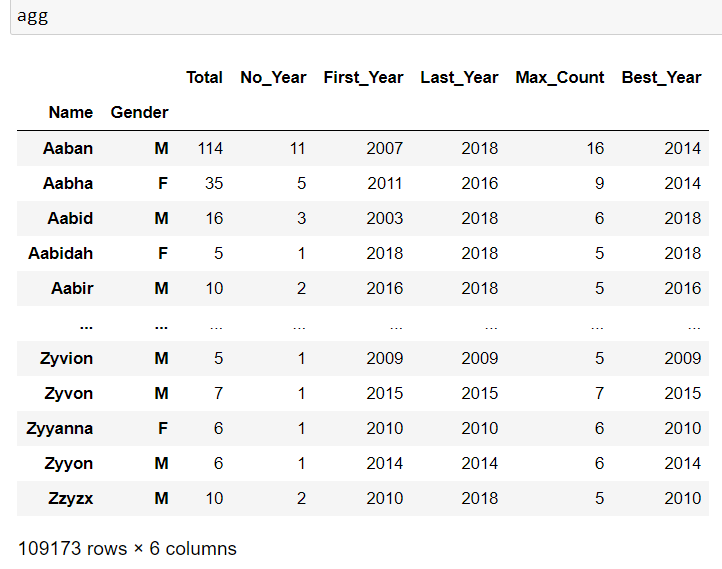

__How to interpret agg (and the first observation Aaban, M):__<br>
- There are in total 114 Male Babies with the name Aaban (Total)<br>
- The combination/entry (Aaban, M) can be found in 11 different years (No_Year)<br>
- The combination/entry (Aaban, M) appeared in the year 2007 for the first time (First_Year)<br>
- The last appearance was in the year 2018 (Last_Year)<br>
- In the most popular year, (Aaban, M) appeared 16 times (Max_Count)
- The most popular year for (Aaban, M) (Best_Year)

In [18]:
df.groupby(["Name", "Gender"], observed=True).Count.sum().reset_index(level = -1)

,Gender,Count
Name,,
Aaban,M,114
Aabha,F,35
Aabid,M,16
Aabidah,F,5
Aabir,M,10
...,...,...
Zyvion,M,5
Zyvon,M,7
Zyyanna,F,6


In [19]:
agg = df.groupby(["Name", "Gender"], observed=True).agg(Total=("Count", "sum"), Numb_Years=("Count", "count"), First_Y=("Year", "min"), Last_Y=("Year", "max"), 
                                         Max_Count=("Count", "max"))
agg

,,Total,Numb_Years,First_Y,Last_Y,Max_Count
Name,Gender,,,,,
Aaban,M,114,11,2007,2018,16
Aabha,F,35,5,2011,2016,9
Aabid,M,16,3,2003,2018,6
Aabidah,F,5,1,2018,2018,5
Aabir,M,10,2,2016,2018,5
...,...,...,...,...,...,...
Zyvion,M,5,1,2009,2009,5
Zyvon,M,7,1,2015,2015,7
Zyyanna,F,6,1,2010,2010,6


In [20]:
def best_year(group):
    return group.nlargest(1, "Count").Year

In [21]:
best_y = df.groupby(["Name", "Gender"], observed=True).apply(best_year, include_groups=False)

In [22]:
best_y

Name     Gender         
Aaban    M       1817711    2014
Aabha    F       1803981    2014
Aabid    M       1953741    2018
Aabidah  F       1940601    2018
Aabir    M       1890403    2016
                            ... 
Zyvion   M       1658038    2009
Zyvon    M       1856007    2015
Zyyanna  F       1675008    2010
Zyyon    M       1824324    2014
Zzyzx    M       1692111    2010
Name: Year, Length: 109173, dtype: int64

In [23]:
best_y.droplevel(-1)

Name     Gender
Aaban    M         2014
Aabha    F         2014
Aabid    M         2018
Aabidah  F         2018
Aabir    M         2016
                   ... 
Zyvion   M         2009
Zyvon    M         2015
Zyyanna  F         2010
Zyyon    M         2014
Zzyzx    M         2010
Name: Year, Length: 109173, dtype: int64

In [24]:
agg["Best_Y"] = best_y.droplevel(-1)
agg

,,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_Y
Name,Gender,,,,,,
Aaban,M,114,11,2007,2018,16,2014
Aabha,F,35,5,2011,2016,9,2014
Aabid,M,16,3,2003,2018,6,2018
Aabidah,F,5,1,2018,2018,5,2018
Aabir,M,10,2,2016,2018,5,2016
...,...,...,...,...,...,...,...
Zyvion,M,5,1,2009,2009,5,2009
Zyvon,M,7,1,2015,2015,7,2015
Zyyanna,F,6,1,2010,2010,6,2010


8. __Reset__ the Index and create a RangeIndex.

In [25]:
agg.reset_index(inplace=True)
agg

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_Y
0,Aaban,M,114,11,2007,2018,16,2014
1,Aabha,F,35,5,2011,2016,9,2014
2,Aabid,M,16,3,2003,2018,6,2018
3,Aabidah,F,5,1,2018,2018,5,2018
4,Aabir,M,10,2,2016,2018,5,2016
...,...,...,...,...,...,...,...,...
109168,Zyvion,M,5,1,2009,2009,5,2009
109169,Zyvon,M,7,1,2015,2015,7,2015
109170,Zyyanna,F,6,1,2010,2010,6,2010
109171,Zyyon,M,6,1,2014,2014,6,2014


9. __Filter__ agg for the combination (Mary, F)

In [28]:
agg[(agg.Name == "Mary") & (agg.Gender == "F")]

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_Y
68679,Mary,F,4125675,139,1880,2018,73985,1921


## Most Popular Names of all Times

10. __Find__ the __10 most popular__ Male and Female Names of all Times (most popular in terms of total count). See Screenshot with final result below.

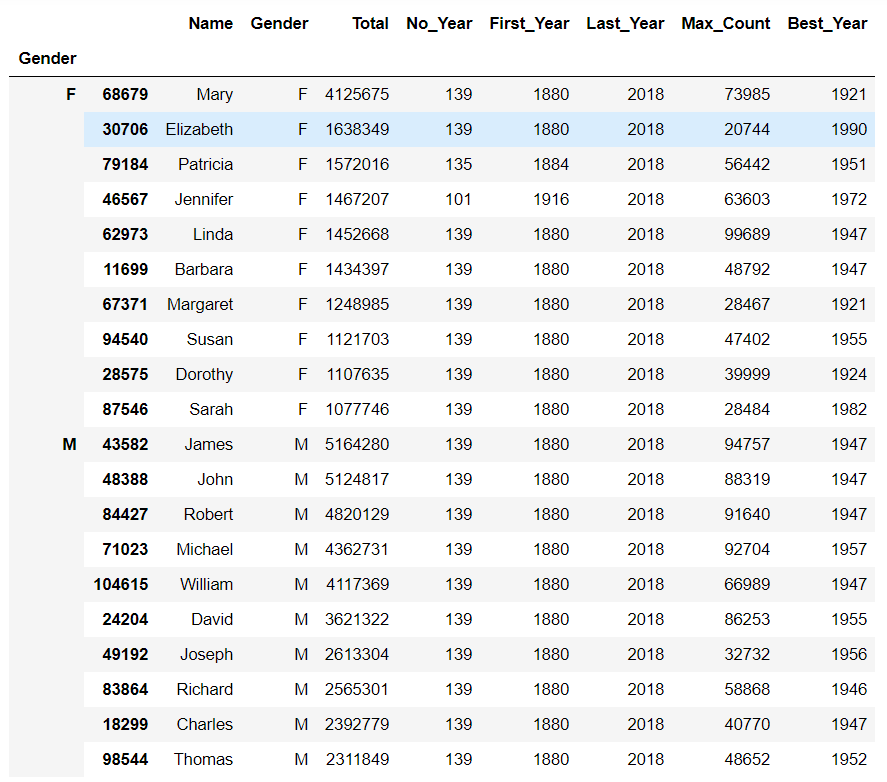

In [29]:
agg.groupby("Gender").apply(lambda x: x.nlargest(10, "Total"), include_groups=False)

C:\Users\pytho\AppData\Local\Temp\ipykernel_10308\2548157060.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg.groupby("Gender").apply(lambda x: x.nlargest(10, "Total"), include_groups=False)


Name    Total  Numb_Years  First_Y  Last_Y  Max_Count  \
Gender                                                                      
F      68679        Mary  4125675         139     1880    2018      73985   
       30706   Elizabeth  1638349         139     1880    2018      20744   
       79184    Patricia  1572016         135     1884    2018      56442   
       46567    Jennifer  1467207         101     1916    2018      63603   
       62973       Linda  1452668         139     1880    2018      99689   
       11699     Barbara  1434397         139     1880    2018      48792   
       67371    Margaret  1248985         139     1880    2018      28467   
       94540       Susan  1121703         139     1880    2018      47402   
       28575     Dorothy  1107635         139     1880    2018      39999   
       87546       Sarah  1077746         139     1880    2018      28484   
M      43582       James  5164280         139     1880    2018      94757   
       48388        John  5124817         139     1880    2018      88319   
       84427      Robert  4820129         139     1880    2018      91640   
       71023     Michael  4362731         139     1880    2018      92704   
       104615    William  4117369         139     1880    2018      66989   
       24204       David  3621322         139     1880    2018      86253   
       49192      Joseph  2613304         139     1880    2018      32732   
       83864     Richard  2565301         139     1880    2018      58868   
       18299     Charles  2392779         139     1880    2018      40770   
       98544      Thomas  2311849         139     1880    2018      48652   

               Best_Y  
Gender                 
F      68679     1921  
       30706     1990  
       79184     1951  
       46567     1972  
       62973     1947  
       11699     1947  
       67371     1921  
       94540     1955  
       28575     1924  
       87546     1982  
M      43582     1947  
       48388     1947  
       84427     1947  
       71023     1957  
       104615    1947  
       24204     1955  
       49192     1956  
       83864     1946  
       18299     1947  
       98544     1952

In [35]:
all_time = agg.groupby("Gender", observed=True).apply(lambda x: x.nlargest(10, "Total"), include_groups=False).reset_index(drop=False)
all_time

,Gender,level_1,Name,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_Y
0,F,68679,Mary,4125675,139,1880,2018,73985,1921
1,F,30706,Elizabeth,1638349,139,1880,2018,20744,1990
2,F,79184,Patricia,1572016,135,1884,2018,56442,1951
3,F,46567,Jennifer,1467207,101,1916,2018,63603,1972
4,F,62973,Linda,1452668,139,1880,2018,99689,1947
5,F,11699,Barbara,1434397,139,1880,2018,48792,1947
6,F,67371,Margaret,1248985,139,1880,2018,28467,1921
7,F,94540,Susan,1121703,139,1880,2018,47402,1955
8,F,28575,Dorothy,1107635,139,1880,2018,39999,1924
9,F,87546,Sarah,1077746,139,1880,2018,28484,1982


## General Trends over time (1880 - 2018)

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

11. __Count__ the total number of __registered Babies per Year__ and visualize. __Create__ the following Plot:

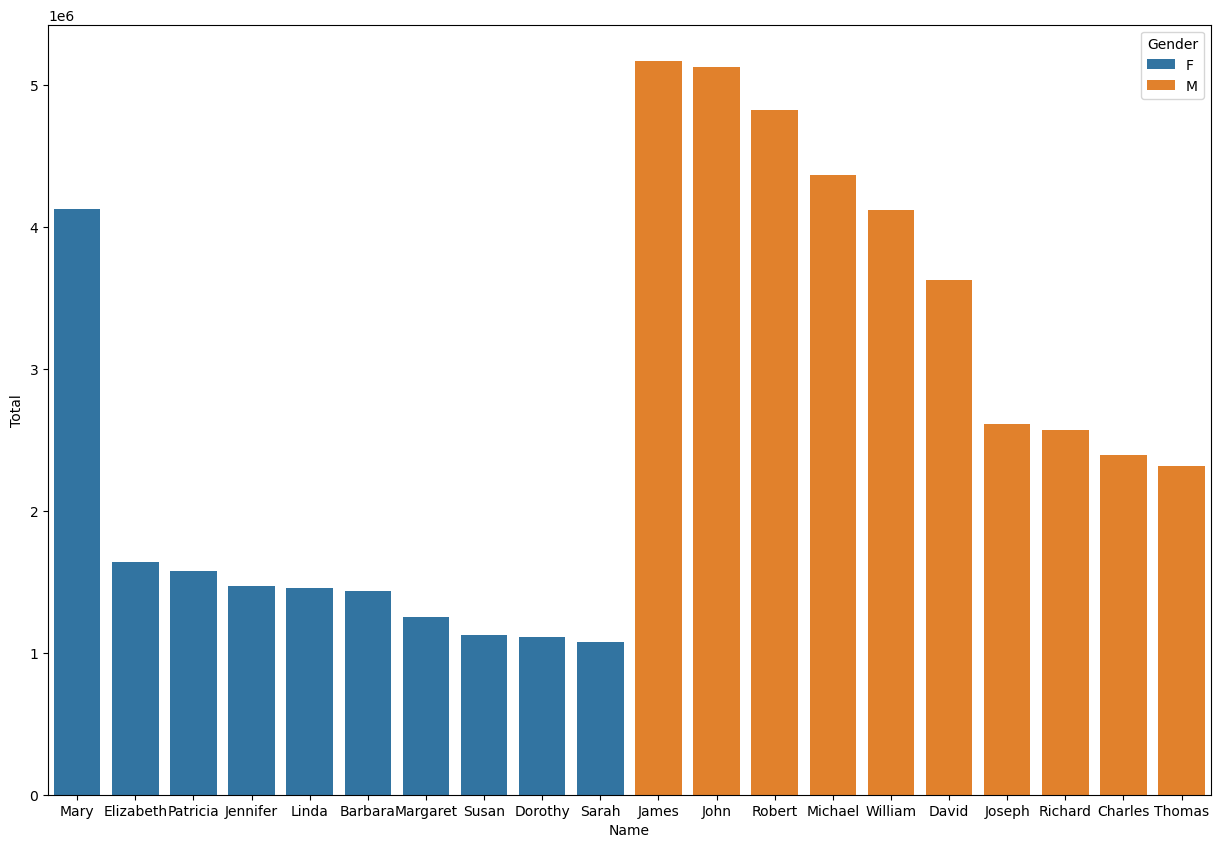

In [39]:
plt.figure(figsize=(15,10))
sns.barplot(x="Name", y="Total", data=all_time, hue="Gender")
plt.show()

In [40]:
pd.options.display.float_format = "{:.0f}".format

In [41]:
babys_per_year = df.groupby("Year").Count.sum()
babys_per_year

Year
1880     201484
1881     192696
1882     221533
1883     216944
1884     243461
         ...   
2014    3698914
2015    3691990
2016    3657797
2017    3561975
2018    3487353
Name: Count, Length: 139, dtype: int64

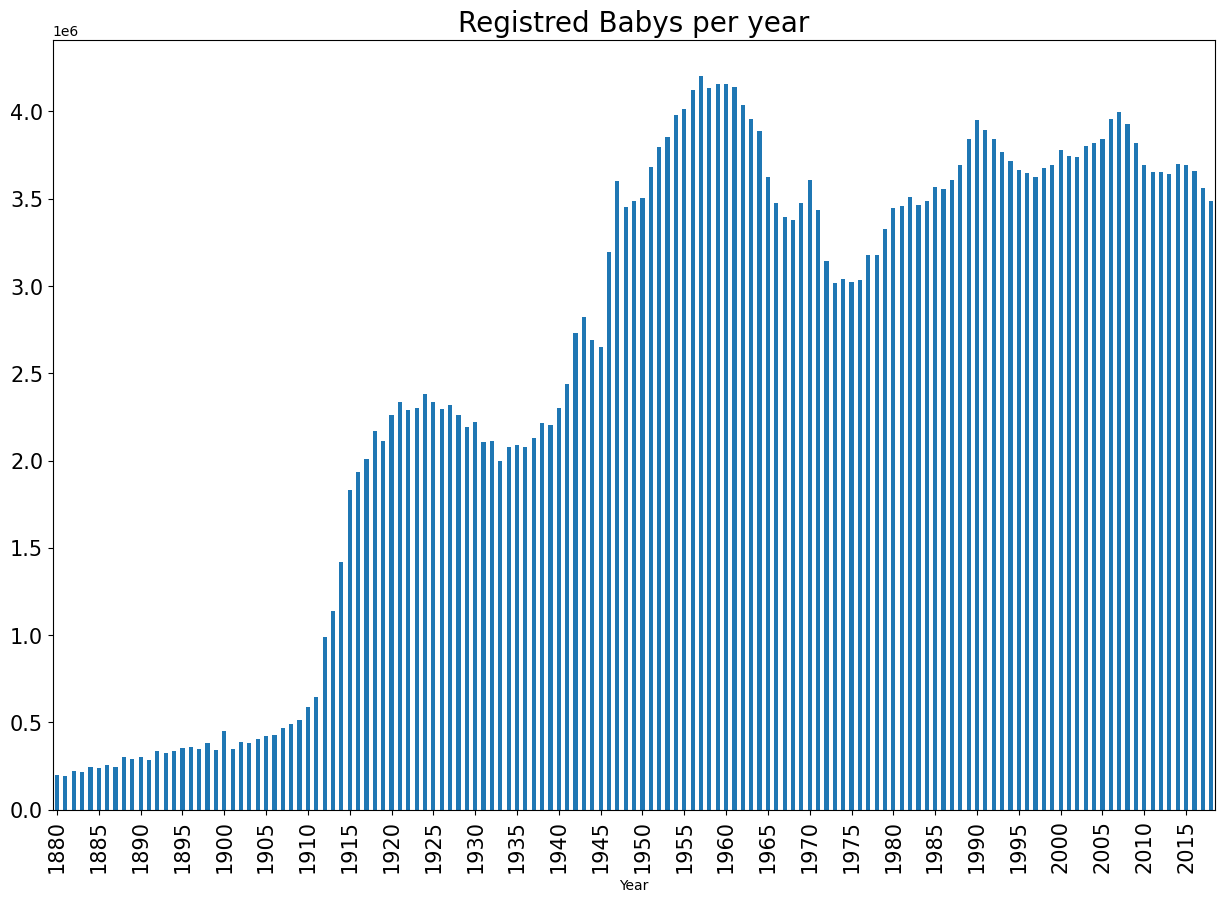

In [51]:
babys_per_year.plot(kind="bar", y="Count", figsize=(15,10), fontsize=15)
plt.xticks(ticks=(range(0, len(babys_per_year), 5)), labels=range(1880, 2019, 5))
plt.title("Registred Babys per year", fontsize=20)
plt.show()

12. __Count__ the total number of __Unique Names per Year__ and visualize. __Create__ the following Plot:

In [52]:
diff_names = df.groupby("Year").Name.count()
diff_names

Year
1880     2000
1881     1935
1882     2127
1883     2084
1884     2297
        ...  
2014    33243
2015    33121
2016    33010
2017    32590
2018    32033
Name: Name, Length: 139, dtype: int64

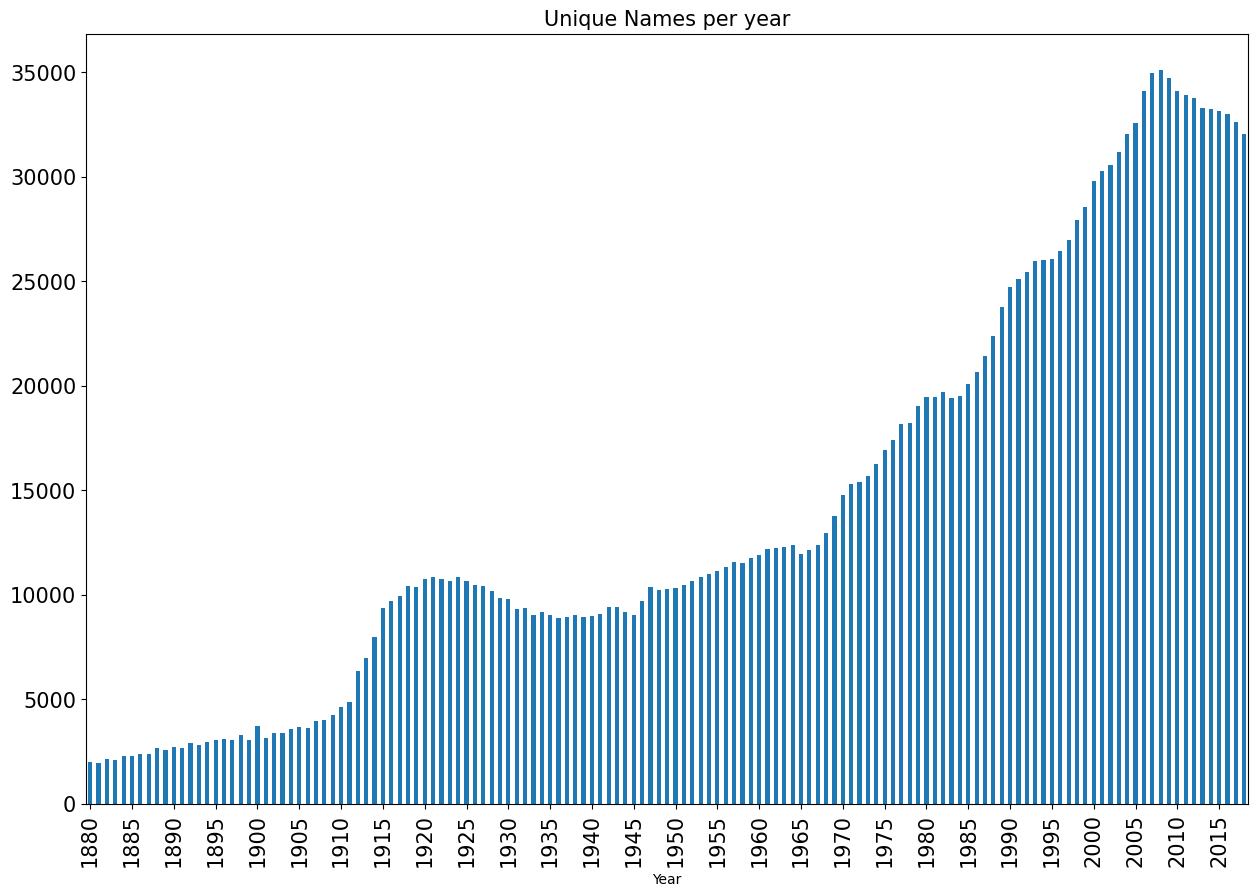

In [61]:
diff_names.plot(kind="bar", y="Count", figsize=(15, 10), fontsize=15)
plt.xticks(ticks=(range(0, len(diff_names), 5)), labels=range(1880, 2019, 5))
plt.title("Unique Names per year", fontsize=15)
plt.show()

## Creating the Features "Popularity" and "Rank"

13. __Add__ the column __"Popularity"__ to df: <br> 

- Popularity in __babies per million__ (example: assume 2,000,000 registered Girl Names in 1950, thereof 100,000 Maries -> Popularity Score in 1950 for (Mary, F) is 100,000 / 2,000,000 * 1,000,000 = 50,000 per million.)  

14. __Add__ the column __"Rank"__ to df: <br> 

- Rank (example: assume Mary is the most popular Girl Name in 1950 -> Rank 1 for (Mary, F) in 1950.

After adding "Popularity" and "Rank", df should look as follows:

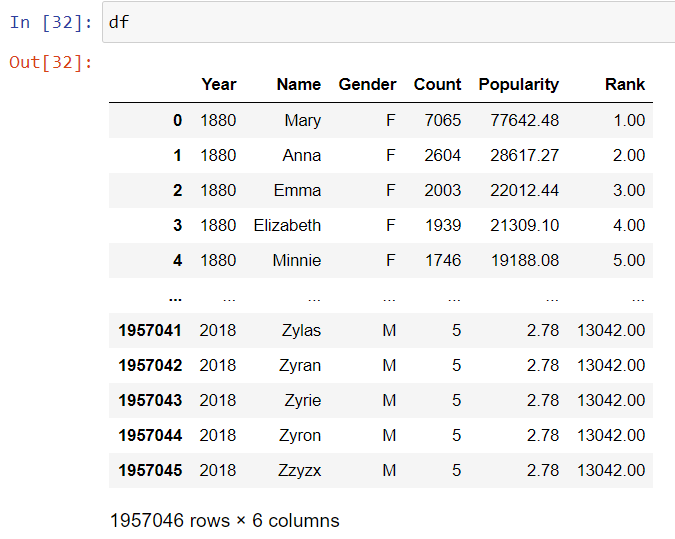

## Visualizing Name Trends over Time

15. __Visualize__ Popularity and Rank over time (see example below).

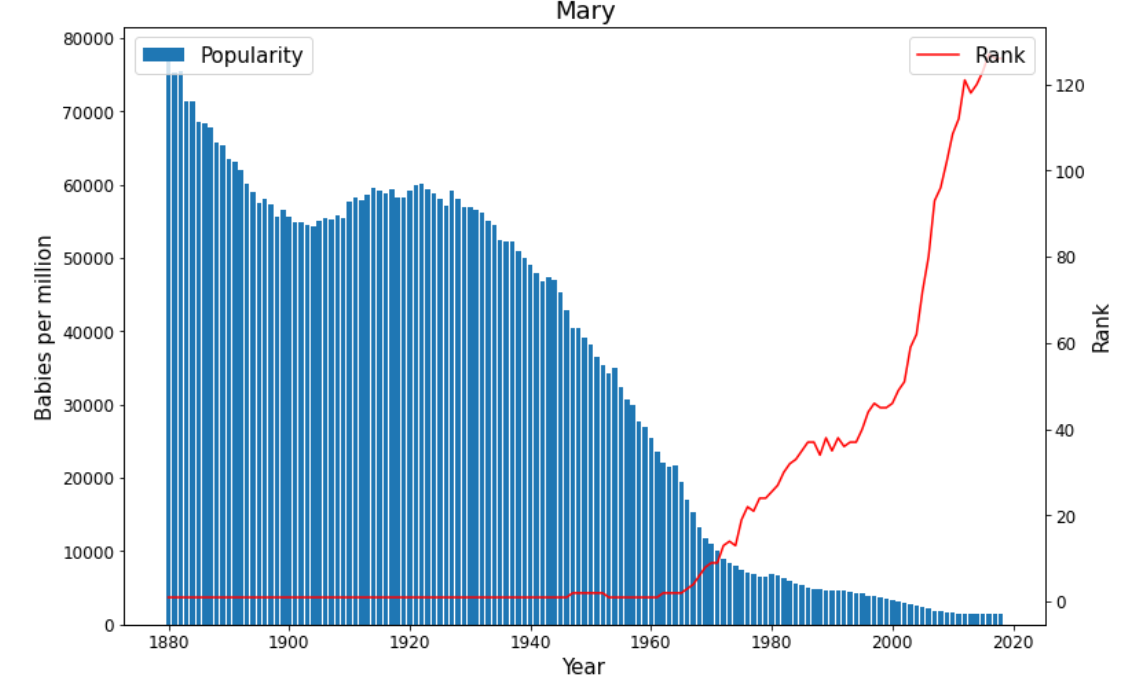

16. __Create__ this plot for all __Evergreen Names__ (see Questions 5. and 6.) (a reusable user-defined function might help)

# Why does a Name´s Popularity suddenly change? (Part 1)

17. __Add__ the additional columns __"Pop_lag1"__ (Popularity one year ago) and __"Pop_diff"__ (change in popularity from previous year to this year) to df.  

18. __Create__ df2 starting with the __year 1900__ (from 1900 till today).

19. __Filter__ df2 and find the __20 largest values__ in "Pop_diff" (get complete rows).

20. __Create__ the popularity/rank plot (see 15. and 16.) for the Names filtered in 19.

21. __Search__ the Web for the Names __"Linda"__, __"Shirley"__ and __"Jason"__ and __find out__ why the popularity suddenly changed/spiked.

## Why does a Name´s Popularity suddenly change? (Part 2)

_No additional assignments on this. Watch the video for some more examples._

## Persistant vs. Spike-Fade Names

_No additional assignments on this. Watch the video for some more advanced examples._

## Most Popular Unisex Names

22. __Find__ the most popular __Unisex Names__ of all times. (Unisex names are names given to Boys and Girls).  

# +++++++++ See some Hints below +++++++++++++

# ++++++++++++++++ Hints++++++++++++++++++++

__Hints for 5. and 6.__<br>
Use most_pop().

__Hints for 7.__


In [26]:
agg = df.groupby(...).agg(Total = (...), No_Year = (...), First_Year = (...), Last_Year = (...), Max_Count = (...))

TypeError: 'ellipsis' object is not callable

Add Best_Year separately with a udf (tricky...)

__Hints for 10.__<br>
Aggregate agg further.

__Hints for 12.__<br>
Treat Instances of Unisex Names (eg. (Marie, F) and (Marie, M)) as different Names.

__Hints for 13.__<br>
Use groupby() and transform()

__Hints for 14.__<br>
Use groupby() and apply(lambda x: x.rank(ascending = False))

__Hints for 17.__<br>
shift() might help.

__Hints for 18.__<br>
difference between "Popularity" and "Pop_lag1".

__Hints for 19.__<br>
use nlargest()